# Practical 2: Hierarchical Clustering and linkage measures

**Course:** WBCS032-05 Introduction to Machine Learning  
**Student Names:**  Winand Metz, Matthias Nijman  
**Student Numbers:**  S6417221, S4667999

---

## Assignment Overview

In this assignment, you will implement the agglomerative hierarchical clustering algorithm as introduced and discussed in class, using Euclidean distance. Consider

(a) different linkage measures: *single*, *average*, *complete*, and *ward* linkage functions.

(b) three different choices for the number of clusters K = 2, 3, 4.

You will work with the data `data_clustering.csv`, which contains 200
two-dimensional feature vectors. There are no labels associated with the data points.

## 1. Introduction (1 point)

Describe the goal of this assignment.

**Your answer here:**

The goal of this assignment is to gain familiarity with the base concepts of clustering and experimenting with different linkage and internal validation measures to see how they behave when applied.

## 2. Methods (3 points)

### 2.1 Explain agglomerative hierarchical clustering algorithm (0.5 points)

Explain the algorithm in a general manner, including different linkage measures.

**Your answer here:**  
The idea is to start with each feature vector being its own cluster. Then we will merge the closest two clusters into one single cluster, and repeat this process until there is only one large cluster remaining.
These are the steps:
- Start with singletons
- Compute the dissimilarity matrix
- Repeat until only one cluster remains:
    - Merge the closest clusters
    - Update the dissimilarity matrix

When computing the distance between different clusters, there are a few different linkage measures that can be used:
- Single linkage: The minimum distance between any pair of points, one from each cluster.
- Complete linkage: The maximum distance between any pair of points, one from each cluster.
- Average linkage: The average of all pairwise distances between points in the two clusters.
- Wards linkage: The increase in within cluster variance. Wards linkage = C-C1-C2 (where C = Variances of both clusters, C1 = variance of cluster one, C2 = variance of cluster two)

### 2.2 Implementation (2.5 points)

You are allowed to implement the algorithm using built-in functions from *sklearn* for linkage measures and the dendrogram. You need to implement the evaluation metrics (incl. silhouette score, within-cluster sum of squares and between-cluster sum of squares) **yourself**. Both the code quality and correctness will be graded.

*__Note:__* **Do not change the cell labels! Themis will use them to automatically grade your submission.**

In [5]:
# Load required libraries
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score

# Data configuration
data_file_path = 'data_clustering.csv'
df = pd.read_csv(data_file_path, header=None)
data = np.array(df)

# Linkage measures
linkage_measures = ["single", "average", "complete", "ward"]

# The number of clusters
clusters_K = [2, 3, 4]

Write code in the cell below to visualize the input data.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       200 non-null    float64
 1   1       200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


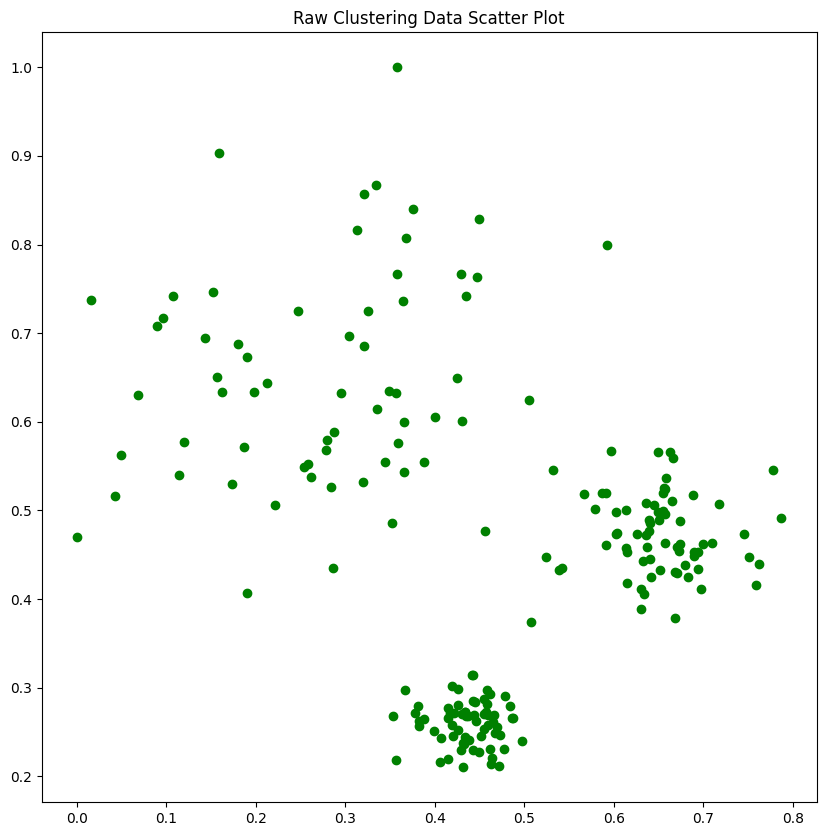

In [16]:
plt.figure(figsize=(10, 10))
plt.title("Raw Clustering Data Scatter Plot")
plt.scatter(df[0], df[1], c = "g")

In the cell below, write code to perform hierarchical clustering using sklearn. Use the different linkage measures and number of clusters specified above. Store the cluster labels for each combination of linkage measure and number of clusters in a dictionary.

In [ ]:
all_labels = {}
for k in clusters_K:
    all_labels[k] = {}
    for measure in linkage_measures:
        all_labels[k][measure] = AgglomerativeClustering(n_clusters=k, linkage=measure).fit(data).labels_

array([0, 1, 1, 2, 2, 1, 3, 2, 3, 1, 2, 0, 3, 1, 2, 1, 2, 1, 1, 2, 3, 3,
       0, 3, 2, 1, 3, 1, 2, 2, 2, 2, 1, 0, 1, 1, 3, 3, 2, 0, 1, 2, 2, 1,
       0, 2, 0, 3, 2, 2, 3, 2, 2, 3, 3, 3, 2, 3, 2, 1, 1, 0, 0, 2, 3, 3,
       2, 2, 1, 3, 2, 2, 3, 1, 3, 3, 2, 3, 1, 2, 2, 2, 2, 3, 3, 2, 3, 3,
       1, 1, 2, 3, 2, 1, 2, 2, 3, 3, 2, 1, 1, 2, 2, 3, 0, 3, 1, 2, 2, 2,
       1, 0, 2, 3, 3, 2, 2, 2, 2, 3, 2, 1, 1, 0, 3, 0, 3, 1, 1, 2, 3, 2,
       2, 0, 2, 3, 3, 3, 3, 3, 0, 2, 1, 2, 3, 3, 3, 3, 3, 2, 3, 3, 3, 2,
       1, 1, 0, 3, 2, 3, 1, 3, 2, 3, 3, 1, 3, 2, 3, 3, 2, 2, 1, 3, 1, 1,
       1, 3, 3, 2, 3, 3, 0, 1, 3, 3, 1, 1, 3, 2, 1, 3, 2, 0, 3, 3, 3, 2,
       3, 3])

In the cells below, complete the implementation of the evaluation metrics (silhouette score, within-cluster sum of squares and between-cluster sum of squares).

In [9]:
def cluster(input_data, labels):
    """
    Clusters the data based on labels. Up to four clusters.

    Args:
        input_data (ndarray): Data points.
        labels (ndarray): Labels of the data points.

    Returns:
        clusters (dict): key = cluster index, value = list of feature vectors.
    """
    clusters = {}
    for i in range(max(labels)+1):
        clusters[i] = []

    for i in range(len(labels)):
        clusters[labels[i]] += [input_data[i]]
    
    return clusters


def avg_inter_cluster_dist(clusters, other_keys, v):
    """
    Compute the average distance from point v to all other points of the nearest cluster.

    Args:
        clusters (dict): key = cluster index, value = list of feature vectors.
        other_keys (list) = List of cluster keys of the clusters that v is not in.
        v (list) = Point (vector) from a cluster. [0=x, 1=y]

    Returns:
        d: Average distance from point v to all other points of the nearest cluster.
    """
    d = float('inf')
    for key in other_keys:
        d = min((1 / (len(clusters[key]))) * sum([np.linalg.norm([v - v2]) for v2 in clusters[key]]), d)
        
    return d

In [10]:
def silhouette_score_defined(input_data, labels):
    """
    Compute the self-defined Silhouette Score.

    Args:
        input_data (ndarray): Data points.
        labels (ndarray): Labels of the data points.

    Returns:
        float: The mean silhouette score for all points.
    """
    clusters = cluster(input_data, labels)

    s = []
    for key in clusters.keys():
        other_keys = list(clusters.keys())
        other_keys.remove(key)

        a = [(1 / (len(clusters[key]) - 1)) * sum([np.linalg.norm(v - v2) for v2 in clusters[key]]) for v in clusters[key]]

        b = [avg_inter_cluster_dist(clusters, other_keys, v) for v in clusters[key]]

        s += [((b[i] - a[i]) / max(a[i], b[i])) for i in range(len(clusters[key]))]

    return np.mean(s)

In [11]:
def compute_wss_bss(input_data, labels):
    """
    Compute Within-Cluster Sum of Squares (WSS) and Between-Cluster Sum of Squares (BSS).

    Args:
        input_data (ndarray): Data points.
        labels (ndarray): Labels of the data points.
        
    Returns:
        tuple: (WSS, BSS)
    """

    # TODO: Implement the WSS and BSS calculation.
    
    pass

## 3. Experimental Results (4 points)

*__Note:__* This section **is graded** by Themis.

### 3.1 Qualitative result

1. Implement `plot_dendrogram(input_data, linkage_measure, cutoff)` - Plot a dendrogram for the given linkage measure and indicate the corresponding cut-off thresholds using dashed horizontal lines.

2. Implement `plot_clustering_results(input_data, k, linkage_measure)` - Plot the clustering results for a given number of clusters and linkage measure.


In [12]:
def plot_dendrogram(input_data, linkage_measure, cutoff):
    """
    Plot a single dendrogram, based on the given parameters.

    Args:
        input_data (ndarray): Data points.
        linkage_measure (str): The linkage measure (e.g. 'single').
        cutoff (list): List of cut-off thresholds.
    """

    # TODO: Implement the dendrogram plotting.
    
    pass

In [13]:
def plot_clustering_results(input_data, k, linkage_measure):
    """
    Plot clustering results for given k and linkage measure.

    Args:
        input_data (ndarray): Data points.
        k (int): Number of clusters.
        linkage_measure (str): Linkage measure used for clustering.
    """
    
    # TODO: Implement the clustering results plotting.
    
    pass

### 3.2 Quantitative result

1. Implement `compute_silhouette_scores(input_data, k, linkage_measure)` - Compute and return the silhouette score for the given clustering configuration.

2. Implement `compute_wss_bss_scores(input_data, k, linkage_measure)` - Compute and return the within-cluster sum of squares (WSS) and between-cluster sum of squares (BSS) for the given clustering configuration.

In [14]:
def compute_silhouette_scores(input_data, k, linkage_measure):
    """
    Compute silhouette scores for different clustering results.

    Args:
        input_data (ndarray): Data points.
        k (int): Number of clusters.
        linkage_measure (str): Linkage measure used for clustering.
        
    Returns:
        float: Silhouette score for the given clustering configuration.
    """

    # TODO: Implement the silhouette score calculation for the given clustering configuration.
    
    pass

In [15]:
def compute_wss_bss_scores(input_data, k, linkage_measure):
    """
    Compute WSS and BSS scores for different clustering results.

    Args:
        input_data (ndarray): Data points.
        k (int): Number of clusters.
        linkage_measure (str): Linkage measure used for clustering.
        
    Returns:
        tuple: WSS and BSS scores for the given clustering configuration.
    """

    # TODO: Implement the WSS and BSS score calculation for the given clustering configuration.
    
    pass

## 4. Discussion (2 points)

Discuss your observations on both the qualitative and quantitative results, and conclusions for the best choice of linkage measures and the number of clusters.

**Your answer here:**

## Contribution

State your individual contribution.

**Your answer here:**  
We worked with pair-programming and we have contributed equally to the assignment.